In [778]:
#import
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go



In [779]:
# ------------------------------
# HYPERPARAMETERS & SETTINGS
# ------------------------------

# Model & Training Config
FEATURES = [
     'year', 'month', 'day','dayofweek','dayofyear', 'isweekend', 'rolling_mean_3', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7'
]
HIDDEN_LAYERS = [128, 64, 32]  # Increase model complexity with more layers
ACTIVATION = nn.ReLU
DROPOUT = 0  # Increase dropout rate to reduce overfitting
LOSS_FN = nn.SmoothL1Loss  # Use SmoothL1Loss for better convergence
OPTIMIZER_FN = optim.Adam
LEARNING_RATE = 0.00001  # Reduce learning rate for more stable training
WEIGHT_DECAY = 0  # Increase weight decay for regularization
EPOCHS = 3000  # Reduce epochs to prevent overfitting
BATCH_SIZE = 100  # Increase batch size for faster training
SEED = 42
TEST_SIZE = 0.2
N_SAMPLES = 1000  # Simulate data for 30 days
BEST_LOSS = float('inf')  # Start with a very high loss
PATIENCE = 50  # Reduce patience to stop earlier if no improvement
PATIENCE_COUNTER = 0 # Counter for early stopping
LAG_DAYS = 2 # Number of lag days for time series
FORECAST_HORIZON = 7  # Forecast horizon


In [780]:
# Set a random seed for reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

# Create a date range starting from January 1, 2025
dates = pd.date_range(start="2025-01-01", periods=N_SAMPLES, freq="D")
# set date as index

# Generate random observations between 20 and 200
observations = np.random.randint(20, 200, size=N_SAMPLES)

# Add some noise to the observations
trend = np.linspace(50, 150, N_SAMPLES)
seasonality = 30 * np.sin(np.linspace(0, 6*np.pi, N_SAMPLES))
noise = np.random.normal(0, 5, N_SAMPLES)
observations = trend + seasonality + noise

# Create the DataFrame
df = pd.DataFrame({
    "dates": dates,
    "observations": observations
})

# increase date data
df['year'] = df['dates'].dt.year
df['month'] = df['dates'].dt.month
df['day'] = df['dates'].dt.day
df['dayofweek'] = df['dates'].dt.dayofweek
df['dayofyear'] = df['dates'].dt.dayofyear
df['isweekend'] = df['dates'].dt.dayofweek >= 5 # 0=Monday, 6=Sunday
df['isweekend'] = df['isweekend'].astype(int)  # Convert boolean to int

#add rolling mean and std
df["rolling_mean_3"] = df["observations"].rolling(window=3).mean()
df["rolling_mean_7"] = df["observations"].rolling(window=7).mean()
df["rolling_std_7"] = df["observations"].rolling(window=7).std()
df["rolling_min_7"] = df["observations"].rolling(window=7).min()
df["rolling_max_7"] = df["observations"].rolling(window=7).max()

#add moving average
df['moving_average'] = df['observations'].rolling(window=7).mean()
#add moving std
df['moving_std'] = df['observations'].rolling(window=7).std()

#set dates as index
df.set_index('dates', inplace=True)

# Function to create lag features
def create_lag_features(df, target_column, lag_days):
    for lag in range(1, lag_days + 1):
        lag_column = f"lag_{lag}"
        df[lag_column] = df[target_column].shift(lag)
        if lag_column not in FEATURES:
            FEATURES.append(lag_column)
    return df

# Apply the function to create lag features
df = create_lag_features(df, "observations", LAG_DAYS)

# Drop rows with NaN values caused by lagging
df.dropna(inplace=True)

#df["lag_ratio"] = df["lag_1"] / (df["lag_2"] + 1e-5)

# Visualization
fig = go.Figure()
fig.add_trace(go.Scatter(x=dates[:200], y=observations[:200], mode='lines', name='Observations', opacity=0.7))

fig.update_layout(
    title="Observations Over Time",
    xaxis_title="Date",
    yaxis_title="Observations",
    legend_title="Legend",
    template="plotly_white"
)

fig.show()

In [781]:
print(df.loc['2027-09-26'])

observations       146.416819
year              2027.000000
month                9.000000
day                 26.000000
dayofweek            6.000000
dayofyear          269.000000
isweekend            1.000000
rolling_mean_3     151.720219
rolling_mean_7     149.590505
rolling_std_7        6.040178
rolling_min_7      139.126876
rolling_max_7      156.401407
moving_average     149.590505
moving_std           6.040178
lag_1              152.342431
lag_2              156.401407
Name: 2027-09-26 00:00:00, dtype: float64


In [802]:
df.tail(40)

,observations,year,month,day,dayofweek,dayofyear,isweekend,rolling_mean_3,rolling_mean_7,rolling_std_7,rolling_min_7,rolling_max_7,moving_average,moving_std,lag_1,lag_2
dates,,,,,,,,,,,,,,,,
2027-08-19,130.861585,2027,8,19,3,231,0,124.418037,123.660140,4.359757,119.539173,130.861585,123.660140,4.359757,119.539173,122.853354
2027-08-20,125.202998,2027,8,20,4,232,0,125.201252,124.462290,3.986193,119.539173,130.861585,124.462290,3.986193,130.861585,119.539173
2027-08-21,135.973448,2027,8,21,5,233,1,130.679343,125.771050,5.920775,119.539173,135.973448,125.771050,5.920775,125.202998,130.861585
2027-08-22,127.955298,2027,8,22,6,234,1,129.710581,126.063394,5.978951,119.539173,135.973448,126.063394,5.978951,135.973448,125.202998
2027-08-23,126.994933,2027,8,23,0,235,0,130.307893,127.054398,5.360571,119.539173,135.973448,127.054398,5.360571,127.955298,135.973448
2027-08-24,127.059915,2027,8,24,1,236,0,127.336715,127.655336,5.037157,119.539173,135.973448,127.655336,5.037157,126.994933,127.955298
2027-08-25,127.979806,2027,8,25,2,237,0,127.344885,128.861140,3.565883,125.202998,135.973448,128.861140,3.565883,127.059915,126.994933
2027-08-26,130.317920,2027,8,26,3,238,0,128.452547,128.783474,3.520685,125.202998,135.973448,128.783474,3.520685,127.979806,127.059915
2027-08-27,142.894925,2027,8,27,4,239,0,133.730884,131.310892,5.999579,126.994933,142.894925,131.310892,5.999579,130.317920,127.979806


In [783]:
# Ensure MinMaxScaler is imported
from sklearn.preprocessing import MinMaxScaler

def create_multi_step_sequences(df, target_column, sequence_length, forecast_horizon):
    data = df.values
    target_idx = df.columns.get_loc(target_column)

    sequences = []
    targets = []

    for i in range(len(df) - sequence_length - forecast_horizon + 1):
        seq = data[i:i + sequence_length]
        target_seq = data[i + sequence_length:i + sequence_length + forecast_horizon, target_idx]
        sequences.append(seq)
        targets.append(target_seq)

    return np.array(sequences), np.array(targets)


def preprocess_lstm_sequences(
    df, features, target_column, batch_size, sequence_length, Forecast_horizon,
    test_size=0.2, scale=True, scale_target=True
):
    df = df.copy()
    feature_scaler = None
    target_scaler = None

    # Scale features
    if scale:
        feature_scaler = MinMaxScaler()
        df[features] = feature_scaler.fit_transform(df[features])

    # Scale target (only if it's not part of features)
    if scale_target:
        target_scaler = MinMaxScaler()
        df[[target_column]] = target_scaler.fit_transform(df[[target_column]])

    # Create sequences using only the relevant columns
    used_cols = features + [target_column]  # Include target for sequencing
    X, y = create_multi_step_sequences(df[used_cols], target_column, sequence_length, Forecast_horizon)

    # Time-based split (no shuffling)
    split_index = int(len(X) * (1 - test_size))
    X_train, X_test = X[:split_index], X[split_index:]
    y_train, y_test = y[:split_index], y[split_index:]

    # Reshape for LSTM: (samples, sequence_length, num_features)
    num_features = len(features)  # Exclude the target column
    X_train = X_train[:, :, :num_features]
    X_test = X_test[:, :, :num_features]

    # Convert to tensors
    X_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_tensor = torch.tensor(y_train, dtype=torch.float32)
    X_test = torch.tensor(X_test, dtype=torch.float32)
    y_test = torch.tensor(y_test, dtype=torch.float32)

    # Create DataLoader
    train_dataset = TensorDataset(X_tensor, y_tensor)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    return train_loader, X_test, y_test, X_tensor, y_tensor, feature_scaler, target_scaler

# ----------------------------
# Call Preprocessing
# ----------------------------
sequence_length = LAG_DAYS

train_loader, X_test, y_test, X_tensor, y_tensor, feature_scaler, target_scaler = preprocess_lstm_sequences(
    df=df,
    features=FEATURES,
    target_column="observations",
    batch_size=BATCH_SIZE,
    sequence_length=LAG_DAYS,
    Forecast_horizon = FORECAST_HORIZON,
    test_size=TEST_SIZE,
    scale=True,
)


In [784]:
print("FEATURES:", FEATURES)


FEATURES: ['year', 'month', 'day', 'dayofweek', 'dayofyear', 'isweekend', 'rolling_mean_3', 'rolling_mean_7', 'rolling_std_7', 'rolling_min_7', 'rolling_max_7', 'lag_1', 'lag_2']


In [785]:
print("Raw X_train shape:", X_tensor.shape)
print("Expected reshape size:", (X_tensor.shape[0], sequence_length, len(FEATURES)))


Raw X_train shape: torch.Size([788, 2, 13])
Expected reshape size: (788, 2, 13)


In [786]:
X_test.shape, y_test.shape, X_tensor.shape, y_tensor.shape

(torch.Size([198, 2, 13]),
 torch.Size([198, 7]),
 torch.Size([788, 2, 13]),
 torch.Size([788, 7]))

In [787]:
# ----------------------------
# Customizable LSTM
# Model
# ----------------------------
class MultiStepLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1, dropout = DROPOUT):
        super(MultiStepLSTM, self).__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_size, output_size)  # output_size = forecast_horizon

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        out = self.dropout(hidden[-1])  # Apply dropout to final hidden state
        return self.fc(out)  # shape: (batch_size, forecast_horizon)



device = torch.device("cuda" if torch.cuda.is_available() else "cpu") # check if cuda is available and use it if it is available otherwise use cpu


model = MultiStepLSTM(
    input_size=len(FEATURES),  # input dimension is the number of features
    hidden_size=HIDDEN_LAYERS[0],  # use the first hidden layer size as the hidden size
    output_size= FORECAST_HORIZON,  # output size is 1 since we are predicting a single value
    num_layers=len(HIDDEN_LAYERS)  # number of layers is the length of HIDDEN_LAYERS
).to(device)

model

MultiStepLSTM(
  (lstm): LSTM(13, 128, num_layers=3, batch_first=True)
  (dropout): Dropout(p=0, inplace=False)
  (fc): Linear(in_features=128, out_features=7, bias=True)
)

In [788]:
# ----------------------------
# Loss & Optimizer
# ----------------------------
loss_fn = LOSS_FN() # create the loss function using the loss function specified in the hyperparameters
optimizer = OPTIMIZER_FN(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY) # create the optimizer using the optimizer specified in the hyperparameters

Epoch 000 | Train Loss: 0.1340 | Test Loss: 0.2439 | Best Test Loss: 0.2439
Epoch 100 | Train Loss: 0.0374 | Test Loss: 0.0703 | Best Test Loss: 0.0703
Epoch 200 | Train Loss: 0.0058 | Test Loss: 0.0021 | Best Test Loss: 0.0021
Epoch 300 | Train Loss: 0.0025 | Test Loss: 0.0014 | Best Test Loss: 0.0012
Early stopping at epoch 315 — no improvement for 50 epochs.


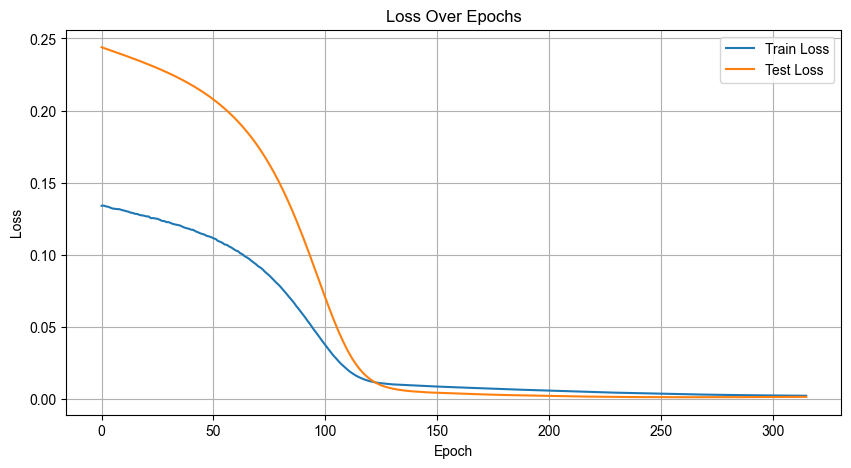

In [789]:
# ----------------------------
# Training Loop + Evaluation
# ----------------------------

train_losses = []
test_losses = []

BEST_LOSS = float("inf")
PATIENCE_COUNTER = 0

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        # Reshape input to match LSTM expected input shape: (batch_size, sequence_length, input_size)
        # Ensure input shape matches LSTM expected input shape: (batch_size, sequence_length, input_size)
        # No need to unsqueeze here as the input is already in the correct shape

        preds = model(xb)  # should be shape: (batch_size, forecast_horizon)

        # Ensure both preds and yb have the same shape
        if preds.ndim == 1:
            preds = preds.unsqueeze(1)  
        if yb.ndim == 1:
            yb = yb.unsqueeze(1)  

        loss = loss_fn(preds, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Average training loss
    avg_train_loss = running_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # ----------------------
    # Evaluate on Test Data
    # ----------------------
    model.eval()
    with torch.no_grad():
        y_pred_test = model(X_test.to(device))
        test_loss = loss_fn(y_pred_test, y_test.to(device)).item()
        test_losses.append(test_loss)

        # Early Stopping Logic
        if test_loss < BEST_LOSS:
            BEST_LOSS = test_loss
            PATIENCE_COUNTER = 0
            best_model_state = model.state_dict()
        else:
            PATIENCE_COUNTER += 1

        if PATIENCE_COUNTER >= PATIENCE:
            print(f"Early stopping at epoch {epoch} — no improvement for {PATIENCE} epochs.")
            break

    # Logging
    if epoch % 100 == 0 or epoch == EPOCHS - 1:
        print(f"Epoch {epoch:03d} | Train Loss: {avg_train_loss:.4f} | Test Loss: {test_loss:.4f} | Best Test Loss: {BEST_LOSS:.4f}")

# Load the best model state after training
model.load_state_dict(best_model_state)

# ----------------------------
# Plot Loss Curve
# ----------------------------
plt.rcParams['font.family'] = 'Arial'
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(test_losses, label="Test Loss")
plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


In [790]:
model.eval()
with torch.no_grad():
    y_pred = model(X_test.to(device)).cpu().numpy()
    y_true = y_test.cpu().numpy()
    y_pred = target_scaler.inverse_transform(y_pred)
    y_true = target_scaler.inverse_transform(y_true)

In [805]:
last_10_dates = df.index[-10:]  # Get the last 10 dates
last_10_values = y_true[-10:]  # Get the last 10 elements of the array

print("Dates:", last_10_dates)
print("Values:", last_10_values)

Dates: DatetimeIndex(['2027-09-18', '2027-09-19', '2027-09-20', '2027-09-21',
               '2027-09-22', '2027-09-23', '2027-09-24', '2027-09-25',
               '2027-09-26', '2027-09-27'],
              dtype='datetime64[ns]', name='dates', freq=None)
Values: [[143.98611 145.17677 137.01833 139.36438 142.40047 154.72632 146.75468]
 [145.17677 137.01833 139.36438 142.40047 154.72632 146.75468 139.97087]
 [137.01833 139.36438 142.40047 154.72632 146.75468 139.97087 146.86734]
 [139.36438 142.40047 154.72632 146.75468 139.97087 146.86734 139.12688]
 [142.40047 154.72632 146.75468 139.97087 146.86734 139.12688 150.26337]
 [154.72632 146.75468 139.97087 146.86734 139.12688 150.26337 155.71527]
 [146.75468 139.97087 146.86734 139.12688 150.26337 155.71527 156.40141]
 [139.97087 146.86734 139.12688 150.26337 155.71527 156.40141 152.34242]
 [146.86734 139.12688 150.26337 155.71527 156.40141 152.34242 146.41681]
 [139.12688 150.26337 155.71527 156.40141 152.34242 146.41681 143.4955 ]]


In [791]:
def forecast_multistep(model, initial_sequence, target_scaler=None):
    model.eval()
    with torch.no_grad():
        input_seq = initial_sequence.unsqueeze(0)  # shape: (1, seq_len, features)
        prediction = model(input_seq)              # shape: (1, forecast_horizon)
        prediction = prediction.squeeze(0).cpu().numpy()  # → (forecast_horizon,)

        # Optional: clamp before inverse scaling
        prediction = np.clip(prediction, 0, 1)

        if target_scaler:
            prediction = target_scaler.inverse_transform(prediction.reshape(-1, 1)).flatten()

    return prediction


# Use final input sequence from test set
initial_sequence = X_test[-1]  # shape: (sequence_length, num_features)

# Use the fixed function we discussed
future_predictions = forecast_multistep(model, initial_sequence, target_scaler=target_scaler)
print("y_pred shape:", y_pred.shape)  # Should be (samples, forecast_horizon)
print("First forecast (multi-step):", future_predictions)

# Reset index to access 'dates' as a column
df_reset = df.reset_index()

# Get the last observed sequence from the dataset (used for forecasting)
sequence_length = initial_sequence.shape[0]  # e.g., LAG_DAYS
# Get just the target column from the sequence (assuming it's the last feature)

# Unscale using target scaler
# Get the actual unscaled target values for the last N days
recent_values = df["observations"].values[-7:]

print("Future predictions:", future_predictions)
# unscale the recent values
print("Recent values:", recent_values)




y_pred shape: (198, 7)
First forecast (multi-step): [155.6574  150.85269 153.3849  146.54428 155.12682 153.3484  151.40895]
Future predictions: [155.6574  150.85269 153.3849  146.54428 155.12682 153.3484  151.40895]
Recent values: [139.12687555 150.26338396 155.71527463 156.40140665 152.34243054
 146.41681898 143.49549122]


In [792]:
# Define last_date as the last date in the DataFrame's index
last_date = df.index[-1]

# Create future date range
future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=len(future_predictions), freq="D")

# Ensure recent_dates and recent_values lengths match
recent_dates = pd.date_range(end=last_date, periods=7, freq="D")

# actual vs predicted
# Ensure all arrays have the same length
min_length = min(len(recent_dates), len(recent_values.flatten()), len(future_dates), len(future_predictions))

data = pd.DataFrame({
	"recent_dates": recent_dates[-min_length:],  # Trim to match the minimum length
	"recent_values": recent_values.flatten()[-min_length:],  # Trim to match the minimum length
	"future_dates": future_dates[:min_length],  # Trim to match the minimum length
	"future_predictions": future_predictions[:min_length]  # Trim to match the minimum length
})
print(data.head(10))

# Plot
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=recent_dates,
    y=recent_values,
    mode='lines+markers',
    name='Last Observations'
))

fig.add_trace(go.Scatter(
    x=future_dates,
    y=future_predictions,
    mode='lines+markers',
    name='Forecast',
    line=dict(color='red')
))

fig.update_layout(
    title="Multi-Step Forecast from Final LSTM Sequence",
    xaxis_title="Date",
    yaxis_title="Observations",
    legend_title="Legend",
    template="plotly_white"
)

fig.show()


  recent_dates  recent_values future_dates  future_predictions
0   2027-09-21     139.126876   2027-09-28          155.657394
1   2027-09-22     150.263384   2027-09-29          150.852692
2   2027-09-23     155.715275   2027-09-30          153.384903
3   2027-09-24     156.401407   2027-10-01          146.544281
4   2027-09-25     152.342431   2027-10-02          155.126816
5   2027-09-26     146.416819   2027-10-03          153.348404
6   2027-09-27     143.495491   2027-10-04          151.408951


In [816]:
#test prediction accuracy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# Ensure y_true and y_pred have the same length
min_length = min(len(y_true), len(y_pred))

# Calculate metrics
mae = mean_absolute_error(y_true[:min_length].flatten(), y_pred[:min_length].flatten())
mse = mean_squared_error(y_true[:min_length].flatten(), y_pred[:min_length].flatten())
rmse = np.sqrt(mse)
r2 = r2_score(y_true[:min_length].flatten(), y_pred[:min_length].flatten())
mape = np.mean(np.abs((y_true[:min_length] - y_pred[:min_length]) / y_true[:min_length])) * 100
accuracy_score = 100 - mape
accuracy_score_percentage = accuracy_score / 100
print(f"accuracy_score_percentage: {accuracy_score_percentage:.2f}")


# Determine if the model is performing well
is_low_mae = mae < 10  # threshold for low MAE
is_low_mape = mape < 10  # threshold for low MAPE
performance = "Good" if is_low_mae and is_low_mape else "Needs Improvement"

# Print metrics in a dataframe
metrics_df = pd.DataFrame({
    "Test Metric": ["MAE", "MSE", "RMSE", "R2", "MAPE","Performance"],
    "Test Value": [mae, mse, rmse, r2, mape, performance]
})

print(metrics_df)

accuracy_score_percentage: 0.95
   Test Metric Test Value
0          MAE   6.124064
1          MSE  56.575626
2         RMSE   7.521677
3           R2   0.650354
4         MAPE    5.01778
5  Performance       Good


In [801]:
# Evaluate on a true forecast horizon
# Use y_true for the true future values and slice it to match the forecast horizon
true_future = y_true.flatten()[-len(future_predictions):]  # Extract the true future values
mae_forecast = mean_absolute_error(true_future[:N], future_predictions[:N]) # N = 10
mse_forecast = mean_squared_error(true_future[:N], future_predictions[:N])
rmse_forecast = np.sqrt(mse_forecast)
r2_forecast = r2_score(true_future[:N], future_predictions[:N])
mape_forecast = np.mean(np.abs((true_future[:N] - future_predictions[:N]) / true_future[:N])) * 100
# Print forecast metrics
forecast_metrics_df = pd.DataFrame({
    "Forecast Metric": ["MAE", "MSE", "RMSE", "R2", "MAPE"],
    "Forecast Value": [mae_forecast, mse_forecast, rmse_forecast, r2_forecast, mape_forecast]
})
forecast_metrics_df["Forecast Value"] = forecast_metrics_df["Forecast Value"].apply(lambda x: round(x, 4))
forecast_quality = "Good" if mae_forecast < 10 and mape_forecast < 10 else "Needs Improvement"
forecast_metrics_df.loc[len(forecast_metrics_df)] = ["Performance", forecast_quality]
forecast_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=N, freq="D")
print(forecast_metrics_df)

# Create an interactive plot using Plotly
fig = go.Figure()

# Add true future values
fig.add_trace(go.Scatter(
    x=future_dates,
    y=true_future[:N],
    mode='lines+markers',
    name='True Future',
    marker=dict(symbol='circle', size=8),
    line=dict(color='blue')
))

# Add forecasted values
fig.add_trace(go.Scatter(
    x=future_dates,
    y=future_predictions[:N],
    mode='lines+markers',
    name='Forecast',
    marker=dict(symbol='x', size=8),
    line=dict(color='red')
))

# Update layout for better interactivity
fig.update_layout(
    title="Interactive Forecast vs. Actual (Next N Days)",
    xaxis_title="Day",
    yaxis_title="Observations",
    xaxis=dict(showgrid=True),
    yaxis=dict(showgrid=True),
    legend_title="Legend",
    template="plotly_white"
)

# Show the interactive plot
fig.show()


  Forecast Metric Forecast Value
0             MAE         6.7053
1             MSE        70.6602
2            RMSE          8.406
3              R2        -1.0024
4            MAPE         4.5928
5     Performance           Good


In [820]:
def test_forecast_from_date(
    df, model, feature_scaler, target_scaler,
    forecast_date, FEATURES, target_column="observations",
    lag_days=7, horizon=5
):
    df = df.copy()
    df = df.sort_values("dates").reset_index(drop=True)

    # Check if forecast date exists
    if forecast_date not in df["dates"].values:
        raise ValueError("The forecast date is not in the dataset.")

    idx = df[df["dates"] == forecast_date].index[0]

    if idx < lag_days:
        raise ValueError("Not enough data before the selected date to form a lag sequence.")

    # Get the lag window of features (the input to the model)
    input_sequence = df.iloc[idx - lag_days:idx]
    input_features = input_sequence[FEATURES].values.astype(np.float32)

    # Scale features using feature scaler
    scaled_input = feature_scaler.transform(input_features)
    input_tensor = torch.tensor(scaled_input).unsqueeze(0).to(torch.float32)

    # Forecast
    model.eval()
    with torch.no_grad():
        forecast_scaled = model(input_tensor).cpu().numpy().flatten()
        forecast_unscaled = target_scaler.inverse_transform(forecast_scaled.reshape(-1, 1)).flatten()

    # True future values for comparison
    true_start = idx
    true_end = idx + horizon
    if true_end > len(df):
        raise ValueError("Not enough future values available in dataset for comparison.")

    true_values = df[target_column].iloc[true_start:true_end].values
    forecast_dates = df["dates"].iloc[true_start:true_end].values
    average_mape = np.mean(np.abs((true_values - forecast_unscaled) / true_values)) * 100
    accuracy_score = 100 - average_mape / 100

    # Build results DataFrame
    result = pd.DataFrame({
        "date": forecast_dates,
        "forecast": forecast_unscaled,
        "true": true_values,
        "error": forecast_unscaled - true_values
    })
    result["abs_error"] = result["error"].abs()
    result["mape"] = (result["abs_error"] / result["true"]) * 100

    return result


In [821]:
# Reset the index to make 'dates' a regular column
df_reset = df.reset_index()

forecast_result = test_forecast_from_date(
    df=df_reset,
    model=model,
    feature_scaler=feature_scaler,
    target_scaler=target_scaler,
    FEATURES=FEATURES,
    forecast_date=pd.Timestamp("2027-09-21"),
    lag_days=LAG_DAYS,
    horizon=FORECAST_HORIZON
)

print(forecast_result)


        date    forecast        true      error  abs_error       mape
0 2027-09-21  155.657394  139.126876  16.530519  16.530519  11.881614
1 2027-09-22  150.852692  150.263384   0.589308   0.589308   0.392183
2 2027-09-23  153.384903  155.715275  -2.330372   2.330372   1.496559
3 2027-09-24  146.544281  156.401407  -9.857126   9.857126   6.302453
4 2027-09-25  155.126801  152.342431   2.784370   2.784370   1.827705
5 2027-09-26  153.348404  146.416819   6.931585   6.931585   4.734145
6 2027-09-27  151.408951  143.495491   7.913460   7.913460   5.514779


/Users/jaytlinaskew/opt/anaconda3/lib/python3.9/site-packages/sklearn/utils/validation.py:2739: UserWarning:

X does not have valid feature names, but MinMaxScaler was fitted with feature names



#save the dataframe to a csv file
params.to_csv("/Users/jaytlinaskew/GitRepository/TimeSeries-Analysis/data/Performance_Data/Neural_Networks/Regression/NextObserved.csv", index=False)